# Example code : using multi layer perceptron

In [77]:
%load_ext cudf.pandas
import numpy as np
import pandas as pd

The cudf.pandas extension is already loaded. To reload it, use:
  %reload_ext cudf.pandas


In [78]:
df = pd.read_csv("/kaggle/input/datasets/organizations/crowdflower/twitter-airline-sentiment/Tweets.csv")

In [79]:
df.isna().sum()

tweet_id                            0
airline_sentiment                   0
airline_sentiment_confidence        0
negativereason                   5462
negativereason_confidence        4118
airline                             0
airline_sentiment_gold          14600
name                                0
negativereason_gold             14608
retweet_count                       0
text                                0
tweet_coord                     13621
tweet_created                       0
tweet_location                   4733
user_timezone                    4820
dtype: int64

In [80]:
df = df.drop(columns=['tweet_id','airline_sentiment_gold','name','negativereason_gold','text'])
df.sample(6)

,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,retweet_count,tweet_coord,tweet_created,tweet_location,user_timezone
2575,negative,0.6333,Cancelled Flight,0.3222,United,0,None,2015-02-20 23:20:49 -0800,Coming to a City Near You,Central Time (US & Canada)
1456,negative,1.0000,Lost Luggage,0.3682,United,0,"[45.67925887, -111.04844481]",2015-02-22 20:10:26 -0800,GLP,Eastern Time (US & Canada)
2133,negative,0.6809,Cancelled Flight,0.6809,United,0,None,2015-02-21 19:59:27 -0800,San Francisco,Pacific Time (US & Canada)
11120,negative,1.0000,Flight Attendant Complaints,0.635,US Airways,0,None,2015-02-19 11:28:37 -0800,None,Eastern Time (US & Canada)
3059,positive,0.6576,None,nan,United,0,None,2015-02-20 05:07:21 -0800,houston paris nyc,Central Time (US & Canada)
14175,negative,1.0000,Customer Service Issue,0.3622,American,0,None,2015-02-22 16:43:18 -0800,Tucson,Pacific Time (US & Canada)


In [81]:
import datetime as dt

In [82]:
df['tweet_created'] = pd.to_datetime(df['tweet_created'])
df['day_name'] = df['tweet_created'].dt.day_name()
df['tweet_created'] = df['tweet_created'].dt.date
df.sample(5)

,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,retweet_count,tweet_coord,tweet_created,tweet_location,user_timezone,day_name
5003,negative,1.0000,Customer Service Issue,1.0000,Southwest,0,None,2015-02-22,None,None,Sunday
3380,neutral,1.0000,None,NaN,United,0,None,2015-02-19,None,None,Thursday
8003,positive,0.6322,None,NaN,Delta,0,None,2015-02-20,"New York, NY",None,Friday
10019,negative,0.6867,Can't Tell,0.6867,US Airways,0,None,2015-02-22,Boston,Quito,Sunday
3903,negative,1.0000,Lost Luggage,1.0000,United,0,None,2015-02-18,None,None,Wednesday


In [83]:
df.isna().sum().reset_index()

,index,0
0,airline_sentiment,0
1,airline_sentiment_confidence,0
2,negativereason,5462
3,negativereason_confidence,4118
4,airline,0
5,retweet_count,0
6,tweet_coord,13621
7,tweet_created,0
8,tweet_location,4733
9,user_timezone,4820


In [84]:
pd.DataFrame({
    'NULL VALUES':df.isna().sum(),
    'UNIQUE VALUES':df.nunique(),
    'DTYPES':df.dtypes
})

,NULL VALUES,UNIQUE VALUES,DTYPES
airline_sentiment,0,3,object
airline_sentiment_confidence,0,1023,float64
negativereason,5462,10,object
negativereason_confidence,4118,1410,float64
airline,0,6,object
retweet_count,0,18,int64
tweet_coord,13621,832,object
tweet_created,0,9,object
tweet_location,4733,3081,object
user_timezone,4820,85,object


In [85]:
# # printing only object and string data
df_str = df.select_dtypes(include='object').astype(str)

In [86]:
# meging the string data into df
df.merge(df_str)
df.sample(5)

,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,retweet_count,tweet_coord,tweet_created,tweet_location,user_timezone,day_name
2280,negative,1.0,Customer Service Issue,0.6571,United,0,None,2015-02-21,New York City,Eastern Time (US & Canada),Saturday
6741,negative,1.0,Customer Service Issue,0.6364,Southwest,0,None,2015-02-17,America,None,Tuesday
3331,negative,1.0,Customer Service Issue,0.3667,United,0,None,2015-02-19,None,None,Thursday
1598,negative,1.0,Lost Luggage,1.0000,United,0,None,2015-02-22,None,Eastern Time (US & Canada),Sunday
1191,positive,1.0,None,NaN,United,0,None,2015-02-23,"Ashtabula, OH",Central Time (US & Canada),Monday


In [87]:
pd.DataFrame({
    'NULL VALUES':df.isna().sum(),
    'UNIQUE VALUES':df.nunique(),
    'DTYPES':df.dtypes
})

,NULL VALUES,UNIQUE VALUES,DTYPES
airline_sentiment,0,3,object
airline_sentiment_confidence,0,1023,float64
negativereason,5462,10,object
negativereason_confidence,4118,1410,float64
airline,0,6,object
retweet_count,0,18,int64
tweet_coord,13621,832,object
tweet_created,0,9,object
tweet_location,4733,3081,object
user_timezone,4820,85,object


In [88]:
df.select_dtypes(include='object')

,airline_sentiment,negativereason,airline,tweet_coord,tweet_created,tweet_location,user_timezone,day_name
0,neutral,None,Virgin America,None,2015-02-24,None,Eastern Time (US & Canada),Tuesday
1,positive,None,Virgin America,None,2015-02-24,None,Pacific Time (US & Canada),Tuesday
2,neutral,None,Virgin America,None,2015-02-24,Lets Play,Central Time (US & Canada),Tuesday
3,negative,Bad Flight,Virgin America,None,2015-02-24,None,Pacific Time (US & Canada),Tuesday
4,negative,Can't Tell,Virgin America,None,2015-02-24,None,Pacific Time (US & Canada),Tuesday
...,...,...,...,...,...,...,...,...
14635,positive,None,American,None,2015-02-22,None,None,Sunday
14636,negative,Customer Service Issue,American,None,2015-02-22,Texas,None,Sunday
14637,neutral,None,American,None,2015-02-22,"Nigeria,lagos",None,Sunday
14638,negative,Customer Service Issue,American,None,2015-02-22,New Jersey,Eastern Time (US & Canada),Sunday


In [89]:
df['user_timezone'].unique().tolist()

['Eastern Time (US & Canada)',
 'Pacific Time (US & Canada)',
 'Central Time (US & Canada)',
 'America/New_York',
 'Atlantic Time (Canada)',
 'Quito',
 None,
 'Mountain Time (US & Canada)',
 'Vienna',
 'Caracas',
 'Kuala Lumpur',
 'Brisbane',
 'Arizona',
 'London',
 'Tehran',
 'Alaska',
 'Sydney',
 'Irkutsk',
 'Santiago',
 'Amsterdam',
 'Tijuana',
 'Abu Dhabi',
 'Central America',
 'Edinburgh',
 'Jerusalem',
 'Hawaii',
 'Paris',
 'Guam',
 'New Delhi',
 'Stockholm',
 'America/Chicago',
 'Berlin',
 'Madrid',
 'Athens',
 'Brussels',
 'Taipei',
 'Rome',
 'Beijing',
 'Mexico City',
 'Bern',
 'Singapore',
 'Indiana (East)',
 'Melbourne',
 'Saskatchewan',
 'Casablanca',
 'Brasilia',
 'Kyiv',
 'Bucharest',
 'Greenland',
 'Prague',
 'New Caledonia',
 'Bogota',
 'Seoul',
 'Sarajevo',
 'Wellington',
 'Bangkok',
 'Warsaw',
 'Copenhagen',
 'Hong Kong',
 'Guadalajara',
 'Mid-Atlantic',
 'Mazatlan',
 'Buenos Aires',
 'America/Los_Angeles',
 'Dublin',
 'Lisbon',
 'Newfoundland',
 'Monterrey',
 'Tokyo'

In [90]:
user_timezone_fixes = {
    # Eastern Time Group
    'Eastern Time (US & Canada)': 'Eastern_Time',
    'America/New_York': 'Eastern_Time',
    'America/Detroit': 'Eastern_Time',
    'EST': 'Eastern_Time',
    'Indiana (East)': 'Eastern_Time',
    
    # Central Time Group
    'Central Time (US & Canada)': 'Central_Time',
    'America/Chicago': 'Central_Time',
    'Mexico City': 'Central_Time',
    'Guadalajara': 'Central_Time',
    'Monterrey': 'Central_Time',
    'Central America': 'Central_Time',
    
    # Mountain Time Group
    'Mountain Time (US & Canada)': 'Mountain_Time',
    'Arizona': 'Mountain_Time',
    'America/Boise': 'Mountain_Time',
    'Mazatlan': 'Mountain_Time',
    
    # Pacific Time Group
    'Pacific Time (US & Canada)': 'Pacific_Time',
    'America/Los_Angeles': 'Pacific_Time',
    'Tijuana': 'Pacific_Time',
    
    # Atlantic Group
    'Atlantic Time (Canada)': 'Atlantic_Time',
    'Newfoundland': 'Atlantic_Time'
}


df['user_timezone'] = df['user_timezone'].str.replace(r" \(US & Canada\)", "", regex=True)
df['user_timezone'] = df['user_timezone'].str.replace(" ", "_")

In [91]:
df['user_timezone'].unique()

array(['Eastern_Time', 'Pacific_Time', 'Central_Time', 'America/New_York',
       'Atlantic_Time_(Canada)', 'Quito', None, 'Mountain_Time', 'Vienna',
       'Caracas', 'Kuala_Lumpur', 'Brisbane', 'Arizona', 'London',
       'Tehran', 'Alaska', 'Sydney', 'Irkutsk', 'Santiago', 'Amsterdam',
       'Tijuana', 'Abu_Dhabi', 'Central_America', 'Edinburgh',
       'Jerusalem', 'Hawaii', 'Paris', 'Guam', 'New_Delhi', 'Stockholm',
       'America/Chicago', 'Berlin', 'Madrid', 'Athens', 'Brussels',
       'Taipei', 'Rome', 'Beijing', 'Mexico_City', 'Bern', 'Singapore',
       'Indiana_(East)', 'Melbourne', 'Saskatchewan', 'Casablanca',
       'Brasilia', 'Kyiv', 'Bucharest', 'Greenland', 'Prague',
       'New_Caledonia', 'Bogota', 'Seoul', 'Sarajevo', 'Wellington',
       'Bangkok', 'Warsaw', 'Copenhagen', 'Hong_Kong', 'Guadalajara',
       'Mid-Atlantic', 'Mazatlan', 'Buenos_Aires', 'America/Los_Angeles',
       'Dublin', 'Lisbon', 'Newfoundland', 'Monterrey', 'Tokyo',
       'America/Detroit',

In [92]:
pd.DataFrame({
    'NULL VALUES':df.isna().sum(),
    'UNIQUE VALUES':df.nunique(),
    'DTYPES':df.dtypes
})

,NULL VALUES,UNIQUE VALUES,DTYPES
airline_sentiment,0,3,object
airline_sentiment_confidence,0,1023,float64
negativereason,5462,10,object
negativereason_confidence,4118,1410,float64
airline,0,6,object
retweet_count,0,18,int64
tweet_coord,13621,832,object
tweet_created,0,9,object
tweet_location,4733,3081,object
user_timezone,4820,85,object


In [93]:
df = df.drop(columns='tweet_location')

In [94]:
df.select_dtypes(include=['object']).columns

Index(['airline_sentiment', 'negativereason', 'airline', 'tweet_coord',
       'tweet_created', 'user_timezone', 'day_name'],
      dtype='object')

In [95]:
# using OHE
df_transformed = pd.get_dummies(df[['negativereason', 'airline', 'tweet_coord','user_timezone', 'day_name']])



In [96]:
nulls = df[['negativereason', 'airline', 'tweet_coord','user_timezone', 'day_name']].isna()
nulls.head(4)

,negativereason,airline,tweet_coord,user_timezone,day_name
0,True,False,True,False,False
1,True,False,True,False,False
2,True,False,True,False,False
3,False,False,True,False,False


In [97]:
df_transformed = df_transformed.astype(float)

# 2. Now run your loop
for col in ['negativereason', 'airline', 'tweet_coord', 'user_timezone', 'day_name']:
    temp_cols = [i for i in df_transformed.columns if i.startswith(col + '_')]
    df_transformed.loc[nulls[col], temp_cols] = np.nan

In [98]:
df_transformed.sample(6)

,negativereason_Bad Flight,negativereason_Can't Tell,negativereason_Cancelled Flight,negativereason_Customer Service Issue,negativereason_Damaged Luggage,negativereason_Flight Attendant Complaints,negativereason_Flight Booking Problems,negativereason_Late Flight,negativereason_Lost Luggage,negativereason_longlines,...,user_timezone_Warsaw,user_timezone_Wellington,user_timezone_West_Central_Africa,day_name_Friday,day_name_Monday,day_name_Saturday,day_name_Sunday,day_name_Thursday,day_name_Tuesday,day_name_Wednesday
1284,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,0.0,1.0,0.0,0.0,0.0,0.0,0.0
14338,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,0.0,0.0,0.0,1.0,0.0,0.0,0.0
11003,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4946,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1072,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4552,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [99]:
num_cols = df.select_dtypes(include=['int','float']).columns.tolist()
num_cols

['airline_sentiment_confidence', 'negativereason_confidence', 'retweet_count']

In [100]:
data = pd.concat([df[num_cols], df_transformed, df['airline_sentiment']], axis=1)

In [101]:
data.sample(6)

,airline_sentiment_confidence,negativereason_confidence,retweet_count,negativereason_Bad Flight,negativereason_Can't Tell,negativereason_Cancelled Flight,negativereason_Customer Service Issue,negativereason_Damaged Luggage,negativereason_Flight Attendant Complaints,negativereason_Flight Booking Problems,...,user_timezone_Wellington,user_timezone_West_Central_Africa,day_name_Friday,day_name_Monday,day_name_Saturday,day_name_Sunday,day_name_Thursday,day_name_Tuesday,day_name_Wednesday,airline_sentiment
3069,1.0000,1.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,1.0,0.0,0.0,0.0,0.0,0.0,0.0,negative
9487,1.0000,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,neutral
226,1.0000,1.0,0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,negative
2253,1.0000,1.0,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,negative
3858,0.6793,0.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,neutral
6057,1.0000,1.0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,negative


In [102]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [103]:
data['airline_sentiment'] = le.fit_transform(data['airline_sentiment'])
data['airline_sentiment']

0        1
1        2
2        1
3        0
4        0
        ..
14635    2
14636    0
14637    1
14638    0
14639    1
Name: airline_sentiment, Length: 14640, dtype: int64

In [104]:
print(le.classes_)    # checking for which class got converted into which number

['negative' 'neutral' 'positive']


In [105]:
# using fknni instead of sklearn for gpu acceleration
# but it also contain small utility function like train_test_split, accuracy_score, StandardScaler, and LabelEncoder etc., but for these we will be using normal sklearn

!pip install "fknni[faissgpu]"         # make sure to run this before running cuml for sklearn in kaggle


In [106]:
import cupy as cp
from fknni import FastKNNImputer
knn = FastKNNImputer(n_neighbors=15, strategy='weighted')

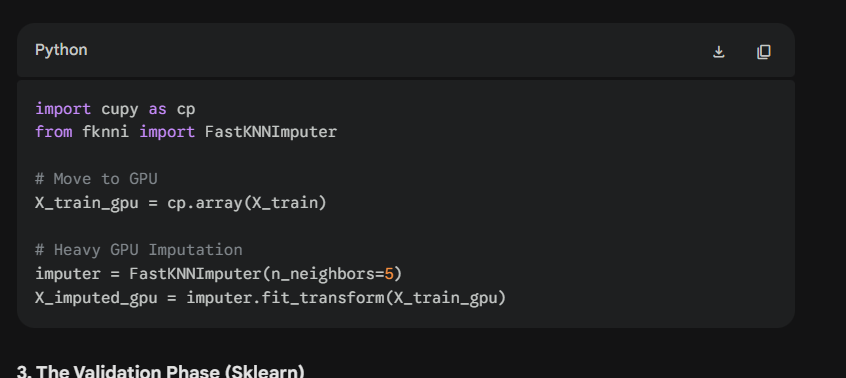

In [107]:
data_gpu = cp.array(data)    # sending the data to gpu for fast acceleration

data_imputed = knn.fit_transform(data_gpu)


/usr/local/lib/python3.12/dist-packages/fknni/knn/knn.py:214: UserWarning: Fallback data (as defined by passed strategy) were used. This warning will only be displayed once.
  self._warn_fallback()


In [108]:
data_imputed

array([[1.        , 0.6527592 , 0.        , ..., 1.        , 0.        ,
        1.        ],
       [0.3486    , 0.        , 0.        , ..., 1.        , 0.        ,
        2.        ],
       [0.6837    , 0.58682601, 0.        , ..., 1.        , 0.        ,
        1.        ],
       ...,
       [1.        , 0.65735964, 0.        , ..., 0.        , 0.        ,
        1.        ],
       [1.        , 0.6659    , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.6771    , 0.        , 0.        , ..., 0.        , 0.        ,
        1.        ]])

In [109]:
new_data = pd.DataFrame(data_imputed.get(), columns=data.columns)       # since out data is stored in gpu, hence to get that data back, we used '.get()'

In [110]:
new_data.isna().sum().sum()       # there is no missing data

np.int64(0)

## Using Multi-layer Perceptron

In [111]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [112]:
new_data[['airline_sentiment_confidence', 'negativereason_confidence', 'retweet_count',]] = scaler.fit_transform(new_data[['airline_sentiment_confidence', 'negativereason_confidence', 'retweet_count',]])

In [113]:
new_data.sample(6)

,airline_sentiment_confidence,negativereason_confidence,retweet_count,negativereason_Bad Flight,negativereason_Can't Tell,negativereason_Cancelled Flight,negativereason_Customer Service Issue,negativereason_Damaged Luggage,negativereason_Flight Attendant Complaints,negativereason_Flight Booking Problems,...,user_timezone_Wellington,user_timezone_West_Central_Africa,day_name_Friday,day_name_Monday,day_name_Saturday,day_name_Sunday,day_name_Thursday,day_name_Tuesday,day_name_Wednesday,airline_sentiment
2643,0.613122,1.212297,1.230099,0.000000,0.0,0.0,0.000000,0.0,1.000000,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
11614,0.613122,0.039416,1.230099,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
8531,0.613122,0.025113,-0.110828,0.074509,0.0,0.0,0.851126,0.0,0.074366,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0
3000,0.613122,1.212297,-0.110828,0.000000,0.0,0.0,1.000000,0.0,0.000000,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
11356,-1.393335,0.062641,-0.110828,0.000000,0.0,1.0,0.000000,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
12193,-1.240409,-0.952590,-0.110828,0.000000,1.0,0.0,0.000000,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [114]:
from sklearn.model_selection import train_test_split
x = new_data.drop(columns='airline_sentiment')
y = new_data['airline_sentiment']

In [115]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.35, random_state=42)

In [116]:
print(x_train.shape)
print(x_test.shape)

(9516, 943)
(5124, 943)


In [117]:
import tensorflow as tf
from tensorflow.keras import layers, models

In [118]:
model = models.Sequential([
    layers.Dense(10, activation='relu', input_dim=x_train.shape[1]),       # layers_dropout = prevents overfitting
    layers.Dense(6, activation='relu'),
    layers.Dense(5, activation = 'relu'),
    layers.Dense(5, activation = 'softmax'),
    layers.Dense(3, activation = 'softmax')
    
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [119]:
# printing the summary of the model

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 10)             │         9,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 6)              │            66 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 5)              │            35 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 5)              │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 3)              │            18 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,589 (37.46 KB)

 Trainable params: 9,589 (37.46 KB)

 Non-trainable params: 0 (0.00 B)

In [120]:
# setting different parameters for the DL model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

## With `early_stopping`

In [121]:
# writing the code for early stopping if there is  no significant increase in the accuracy

from tensorflow.keras.callbacks import EarlyStopping

# 1. Define the callback
early_stopping = EarlyStopping(
    monitor='val_accuracy',    # What to watch (Validation Accuracy)
    min_delta=0.01,            # The minimum change to qualify as an "improvement" (e.g., 1%)
    patience=5,                # How many epochs to wait before giving up
    verbose=1,                 # Prints a message when it stops
    mode='max',                # We want accuracy to be MAXIMIZED
    restore_best_weights=True  # Crucial! Keeps the weights from the BEST epoch, not the last one
)

In [122]:
# using the model to train the DL model
history = model.fit(x_train, y_train, epochs=200, batch_size=64, validation_data=(x_test, y_test), callbacks=[early_stopping])

Epoch 1/200
149/149 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.3596 - loss: 1.0691 - val_accuracy: 0.6364 - val_loss: 0.8899
Epoch 2/200
149/149 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6217 - loss: 0.8833 - val_accuracy: 0.6364 - val_loss: 0.7985
Epoch 3/200
149/149 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6282 - loss: 0.7816 - val_accuracy: 0.6364 - val_loss: 0.7310
Epoch 4/200
149/149 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6246 - loss: 0.7316 - val_accuracy: 0.6836 - val_loss: 0.6955
Epoch 5/200
149/149 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6727 - loss: 0.7070 - val_accuracy: 0.6803 - val_loss: 0.6764
Epoch 6/200
149/149 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6762 - loss: 0.6847 - val_accuracy: 0.6870 - val_loss: 0.6601
Epoch 7/200
149/149 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6775 - loss: 0.6717 - val_accuracy: 0.7037 - val_loss: 0.6353
Epoch 8/200
149/149 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7025 - loss: 0.6346 - val_acc

In [123]:
prediction = model.predict(x_test)

161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [124]:
prediction

array([[0.05883099, 0.55896634, 0.38220266],
       [0.9750801 , 0.01269105, 0.01222886],
       [0.96436656, 0.01832232, 0.0173111 ],
       ...,
       [0.05943332, 0.55808777, 0.38247895],
       [0.54684496, 0.24634837, 0.2068066 ],
       [0.09142132, 0.5282227 , 0.38035607]], dtype=float32)

In [125]:
prediction = prediction.argmax(axis=1)      # will convert the predicition to its normal original numerical values
prediction

array([1, 0, 0, ..., 1, 0, 1])

In [126]:
le.classes_

array(['negative', 'neutral', 'positive'], dtype=object)

In [127]:
from sklearn.metrics import accuracy_score, confusion_matrix

print(f"ACCURACY SCORE : {np.round(accuracy_score(prediction, y_test), 2) * 100} %")
print()
print(f"CONFUSION MATRIX : \n{confusion_matrix(prediction, y_test)}")

ACCURACY SCORE : 80.0 %

CONFUSION MATRIX : 
[[3169  117  130]
 [  92  932  684]
 [   0    0    0]]


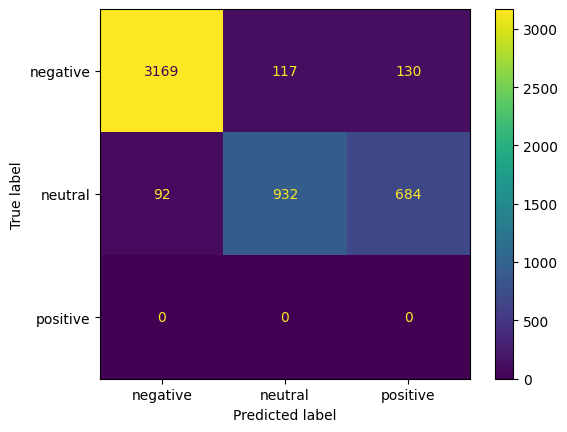

In [128]:
from sklearn.metrics import confusion_matrix,  ConfusionMatrixDisplay
import matplotlib.pyplot as plt


matrix = confusion_matrix(prediction, y_test)
show = ConfusionMatrixDisplay(
    confusion_matrix = matrix,
    display_labels = le.classes_
)
show.plot()
plt.show()

In [129]:
import matplotlib.pyplot as plt

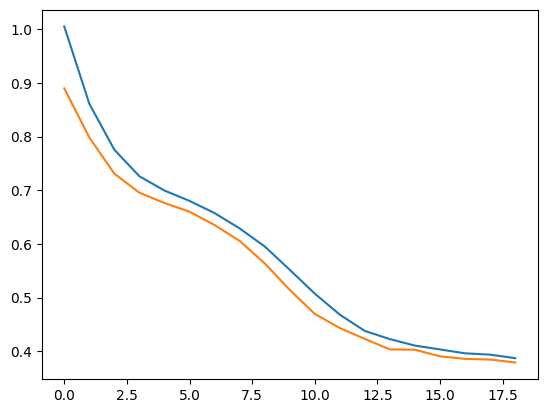

In [130]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.show()

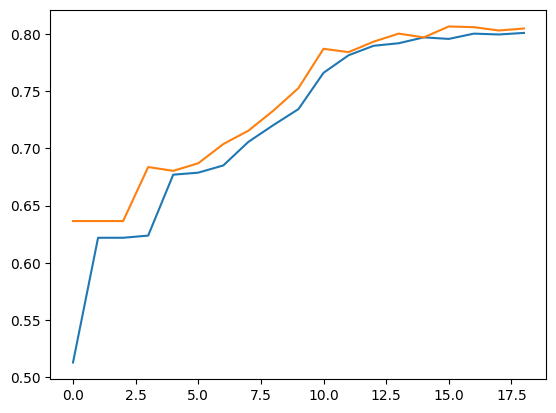

In [131]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.show()

## Without `early_stopping`

In [132]:
history = model.fit(x_train, y_train, epochs=200, batch_size=64, validation_data=(x_test, y_test))

Epoch 1/200
149/149 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.8032 - loss: 0.4070 - val_accuracy: 0.8015 - val_loss: 0.3965
Epoch 2/200
149/149 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7967 - loss: 0.4066 - val_accuracy: 0.8072 - val_loss: 0.3913
Epoch 3/200
149/149 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8021 - loss: 0.3934 - val_accuracy: 0.8011 - val_loss: 0.3867
Epoch 4/200
149/149 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8007 - loss: 0.3921 - val_accuracy: 0.8002 - val_loss: 0.3960
Epoch 5/200
149/149 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7958 - loss: 0.3894 - val_accuracy: 0.8068 - val_loss: 0.3821
Epoch 6/200
149/149 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7976 - loss: 0.3885 - val_accuracy: 0.8050 - val_loss: 0.3767
Epoch 7/200
149/149 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7990 - loss: 0.3844 - val_accuracy: 0.8054 - val_loss: 0.3750
Epoch 8/200
149/149 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8034 - loss: 0.3836 - val_acc

In [133]:
prediction = model.predict(x_test)

161/161 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [134]:
prediction = prediction.argmax(axis=1)      # will convert the predicition to its normal original numerical values
prediction

array([1, 0, 0, ..., 1, 2, 1])

In [135]:
from sklearn.metrics import accuracy_score, confusion_matrix

print(f"ACCURACY SCORE : {np.round(accuracy_score(prediction, y_test), 2) * 100} %")
print()
print(f"CONFUSION MATRIX : \n{confusion_matrix(prediction, y_test)}")

ACCURACY SCORE : 82.0 %

CONFUSION MATRIX : 
[[3195   66   63]
 [  41  747  481]
 [  25  236  270]]


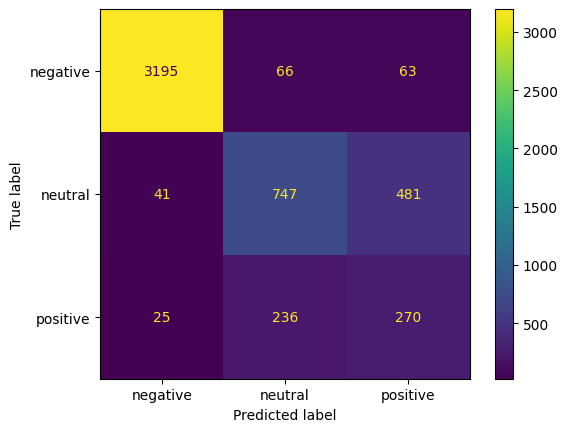

In [136]:
from sklearn.metrics import confusion_matrix,  ConfusionMatrixDisplay
import matplotlib.pyplot as plt


matrix = confusion_matrix(prediction, y_test)
show = ConfusionMatrixDisplay(
    confusion_matrix = matrix,
    display_labels = le.classes_
)
show.plot()
plt.show()

In [137]:
import matplotlib.pyplot as plt

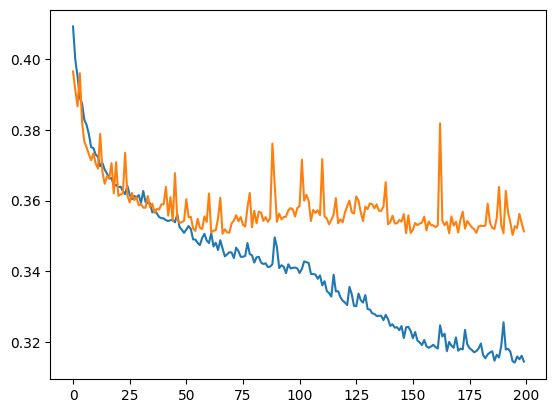

In [138]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.show()

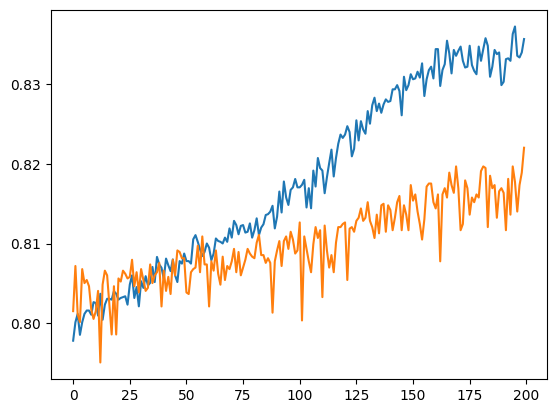

In [139]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.show()

# Overfitting and the "Accuracy Gap" in the first method of using `early stopping`

If you see a large difference between your Training Accuracy (High) and Testing Accuracy (Lower), you are experiencing **Overfitting**.



### 1. What the "Gap" Tells You
The gap represents the difference between **learning** and **memorizing**.
*   **Small Gap:** The model has learned general rules that work on new data.
*   **Large Gap:** The model has memorized the training data "noise" and cannot generalize to new data.



### 2. The Role of Early Stopping
Think of Early Stopping as a **Referee** in a game.

*   **Without Early Stopping:** The model keeps training for all 100 epochs. It eventually learns the "names" of the rows instead of the "logic," causing the Training Loss to keep falling while the Validation Loss starts to climb back **UP**.
*   **With Early Stopping:** The referee blows the whistle the moment the Validation Loss stops improving. This creates a "cleaner" plot that shows where the model was at its healthiest point.



### 3. Why are the Final Metrics similar?
You might notice the Confusion Matrix doesn't change much. This is because:
1.  **Confidence vs. Correctness:** Loss measures "Confidence." Accuracy measures "Correctness." A model can be overfitting (becoming less confident) but still manage to guess the right label (0 or 1) by a tiny margin.
2.  **Dataset Limits:** If the dataset is simple, the model might find its best version very early. Even if it "drifts" during the extra epochs, it might not drift far enough to change its final 0/1 predictions.



### 4. How to Close the Gap
If you want your Training and Testing accuracy to be closer together, try these techniques:

| Technique | How it works |
| :--- | :--- |
| **Dropout Layers** | Randomly "mutes" neurons during training to prevent them from over-relying on specific features. |
| **Reduce Neurons** | If you have 100 neurons for a 10-feature problem, your model is too "big" and will memorize. Try 16 or 32. |
| **L2 Regularization** | Adds a "penalty" to the loss function for weights that are too large, keeping the math simple. |
| **More Data** | The more data the model sees, the harder it is to memorize individual rows. |


___

## Fixing the issue of overfitting with l2 regularization

In [140]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.regularizers import l2

In [163]:
model = models.Sequential([
    # layer 1
    layers.Dense(15, activation='relu', input_dim=x_train.shape[1], kernel_regularizer=regularizers.l2(0.01)),
    layers.Dropout(0.3),

    # layer 2
    layers.Dense(10, activation='relu', kernel_regularizer=regularizers.l2(0.01)),
    layers.Dropout(0.3),

    # layer 3
    layers.Dense(8, activation='relu', kernel_regularizer=regularizers.l2(0.01)),
    layers.Dropout(0.2),

    layers.Dense(5, activation='relu'),
    layers.Dropout(0.2),

    layers.Dense(3, activation='softmax')        # softmax is used only at the very last layer
    
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [164]:
model.compile(optimizer='Adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

### With Early Stopping

In [166]:
from tensorflow.keras.callbacks import EarlyStopping

In [168]:
early_stopping = EarlyStopping(
    monitor = 'val_loss',
    min_delta = 0.01,
    patience = 10,
    verbose = 1,
    mode = 'auto',         # if monitor is val_loss, will choose mode='min', but if monitor is 'val_accuracy', will choose mode='max'
    restore_best_weights=True
)

In [169]:
history = model.fit(x_train, y_train, epochs=150, batch_size=100, validation_data=[x_test, y_test], callbacks=[early_stopping])

Epoch 1/150
96/96 ━━━━━━━━━━━━━━━━━━━━ 9s 50ms/step - accuracy: 0.5351 - loss: 1.3726 - val_accuracy: 0.6364 - val_loss: 0.9866
Epoch 2/150
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6198 - loss: 1.0120 - val_accuracy: 0.6364 - val_loss: 0.8414
Epoch 3/150
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6352 - loss: 0.9036 - val_accuracy: 0.6852 - val_loss: 0.7590
Epoch 4/150
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6535 - loss: 0.8030 - val_accuracy: 0.6895 - val_loss: 0.7144
Epoch 5/150
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6565 - loss: 0.7652 - val_accuracy: 0.7047 - val_loss: 0.6684
Epoch 6/150
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6576 - loss: 0.7395 - val_accuracy: 0.7065 - val_loss: 0.6430
Epoch 7/150
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6761 - loss: 0.6991 - val_accuracy: 0.7207 - val_loss: 0.6181
Epoch 8/150
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6720 - loss: 0.6870 - val_accuracy: 0.7199 - 

In [170]:
prediction = model.predict(x_test)

161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [171]:
prediction = prediction.argmax(axis=1) 
prediction

array([1, 0, 0, ..., 1, 0, 1])

In [172]:
from sklearn.metrics import accuracy_score, confusion_matrix

print(f"ACCURACY SCORE : {np.round(accuracy_score(prediction, y_test), 2) * 100} %")
print()
print(f"CONFUSION MATRIX : \n{confusion_matrix(prediction, y_test)}")

ACCURACY SCORE : 80.0 %

CONFUSION MATRIX : 
[[3159  126  140]
 [ 102  923  674]
 [   0    0    0]]


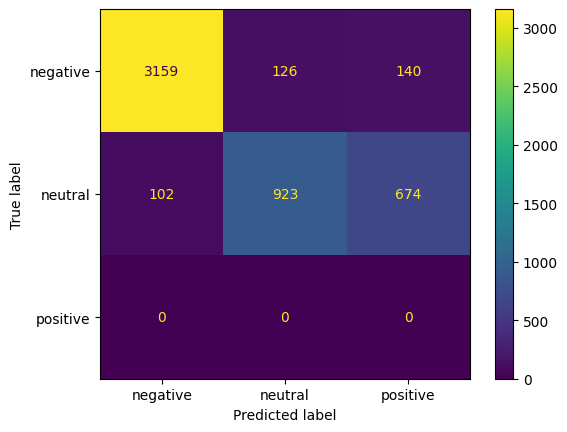

In [173]:
from sklearn.metrics import confusion_matrix,  ConfusionMatrixDisplay
import matplotlib.pyplot as plt


matrix = confusion_matrix(prediction, y_test)
show = ConfusionMatrixDisplay(
    confusion_matrix = matrix,
    display_labels = le.classes_
)
show.plot()
plt.show()

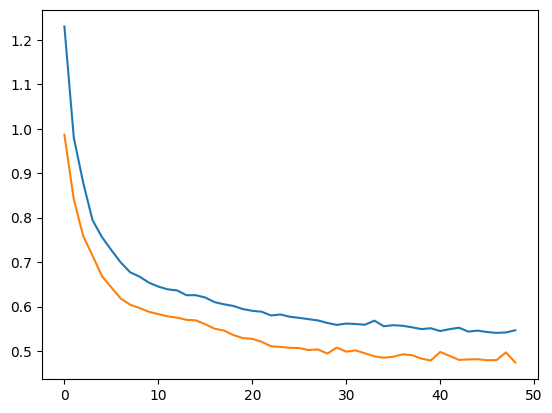

In [174]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.show()

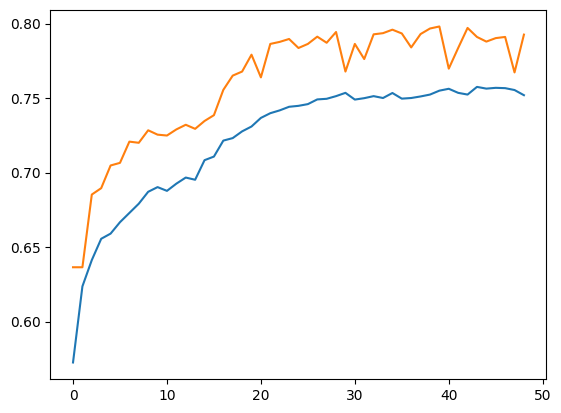

In [175]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.show()

### Without Early Stopping

In [176]:
history = model.fit(x_train, y_train, epochs=150, batch_size=100, validation_data=[x_test, y_test])

Epoch 1/150
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.7603 - loss: 0.5427 - val_accuracy: 0.7947 - val_loss: 0.4800
Epoch 2/150
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7534 - loss: 0.5488 - val_accuracy: 0.7855 - val_loss: 0.4881
Epoch 3/150
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7584 - loss: 0.5440 - val_accuracy: 0.7890 - val_loss: 0.4816
Epoch 4/150
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7567 - loss: 0.5386 - val_accuracy: 0.7955 - val_loss: 0.4755
Epoch 5/150
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7542 - loss: 0.5460 - val_accuracy: 0.7970 - val_loss: 0.4733
Epoch 6/150
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7492 - loss: 0.5507 - val_accuracy: 0.7931 - val_loss: 0.4773
Epoch 7/150
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7601 - loss: 0.5508 - val_accuracy: 0.7941 - val_loss: 0.4752
Epoch 8/150
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7546 - loss: 0.5427 - val_accuracy: 0.8005 - 

In [178]:
prediction = model.predict(x_test)

161/161 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [179]:
prediction = prediction.argmax(axis=1)
prediction

array([1, 0, 0, ..., 1, 0, 0])

In [180]:
from sklearn.metrics import accuracy_score, confusion_matrix

print(f"ACCURACY SCORE : {np.round(accuracy_score(prediction, y_test), 2) * 100} %")
print()
print(f"CONFUSION MATRIX : \n{confusion_matrix(prediction, y_test)}")

ACCURACY SCORE : 80.0 %

CONFUSION MATRIX : 
[[3253  220  230]
 [   8  829  584]
 [   0    0    0]]


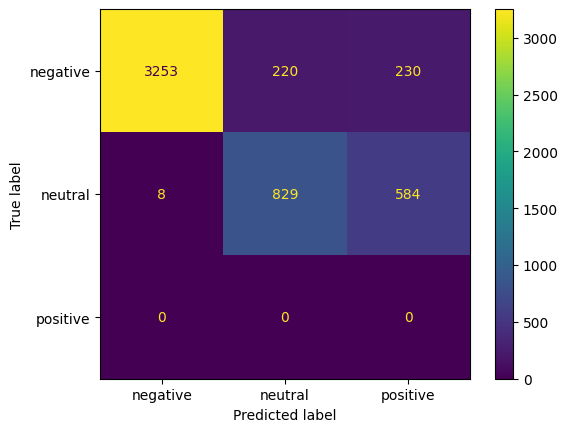

In [181]:
from sklearn.metrics import confusion_matrix,  ConfusionMatrixDisplay
import matplotlib.pyplot as plt


matrix = confusion_matrix(prediction, y_test)
show = ConfusionMatrixDisplay(
    confusion_matrix = matrix,
    display_labels = le.classes_
)
show.plot()
plt.show()

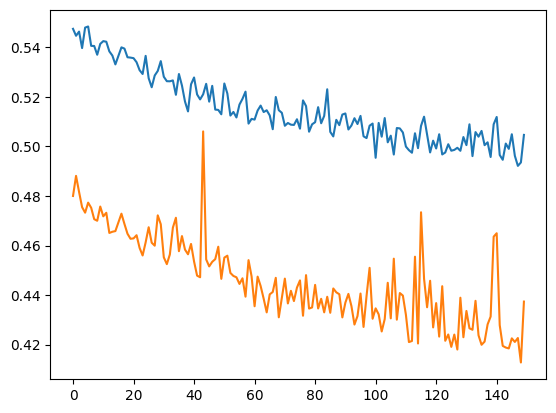

In [183]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.show()

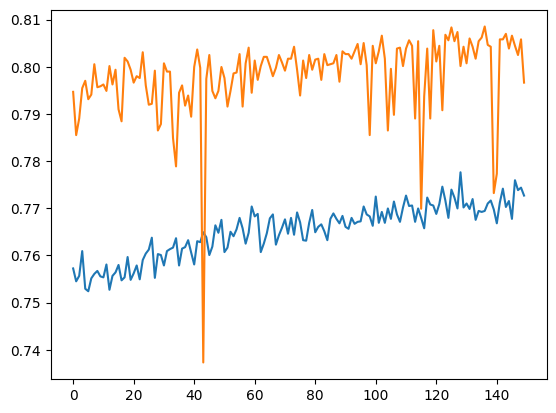

In [185]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.show()

**In the above models there is some overfitting, but this is not bcoz of the model, rather it is bcoz of the data imbalance in positive and neutral class.**

#### So far the third model performed well, with very little overfitting and early stopping to save the computation.

# Is some overfitting normal? (The "Gap" Guide)

Yes. It is practically impossible to achieve a 0% gap between Training and Validation performance. Some amount of overfitting is a natural part of the learning process.



### 1. The "Home Field Advantage"
The model sees the **Training Data** thousands of times during the `fit()` process. It sees the **Validation Data** only once per epoch and never learns from it. Naturally, the model will always be slightly better at the data it "lives" in.



### 2. Identifying a "Healthy" Gap
You don't need to eliminate the gap; you just need to keep it within a reasonable range.

| Gap Status | Performance | Action |
| :-- | :-- | :-- |
| **Healthy** | 2% - 5% difference | **Stop.** This is a well-generalized model. |
| **Noticeable** | 5% - 10% difference | **Optional.** Consider a bit more Dropout or L2. |
| **Unhealthy** | 10%+ difference | **Fix.** The model is memorizing instead of learning. |



### 3. Signal vs. Noise
Every dataset contains:
*   **Signal:** The true patterns (e.g., "High humidity causes rain").
*   **Noise:** Random coincidences (e.g., "It rained on three Tuesdays in a row").

Even with Dropout and Regularization, the model will always try to memorize a tiny bit of **Noise** while learning the **Signal**. This is what creates that final persistent gap.



### 4. The Goal: The "Sweet Spot"
Your ultimate goal is **NOT** to have a 0% gap. Your goal is to achieve the **Highest possible Validation Accuracy.**

*   If you add *too much* Dropout to close the gap, you might make the model so "simple" that its overall accuracy drops. This is called **Underfitting**.
*   The "Sweet Spot" is where the Validation Accuracy is at its peak, even if it is still a few percentage points below the Training line.

### Summary Checklist:
1.  Is the Validation curve still going up (or flat)?
2.  Is the gap less than 5-8%?
3.  Is the Confusion Matrix showing good results for your target class?

**If you answered YES to these, your model is performing normally and is ready for use!**
